# Data

In [34]:
# Libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import librosa
import soundfile as sf
import glob
from collections import Counter
import random
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LSTM, TimeDistributed
from tensorflow.keras.layers import Reshape, BatchNormalization
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import shutil # Để xóa output kaggle

## 1. CREMA_D

In [ ]:
Crema = "/kaggle/input/dataset-ser/Data/CREMA_D/"
Ravdess = "/kaggle/input/dataset-ser/Data/RAVDESS/"
Savee = "/kaggle/input/dataset-ser/Data/SAVEE/"
Tess = "/kaggle/input/dataset-ser/Data/TESS/"


file_emotion = []
file_path = []

# Duyệt qua từng file trong thư mục CREMA_D
for file in os.listdir(Crema):
    if file.endswith(".wav"):
        part = file.split('_')  # VD: 1001_DFA_ANG_XX.wav
        emotion = part[2]       # "ANG"
        file_emotion.append(emotion.lower())  # chuyển về chữ thường: "ang"
        file_path.append(Crema + file)

# Tạo DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)

Crema_df.head()


Crema_df['Emotions'].value_counts()

## 2. Ravdess

In [3]:
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # Có 24 diễn viên
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # Phần tử thứ 3 là cảm xúc
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df['Emotions'] = Ravdess_df['Emotions'].replace({
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'
})
Ravdess_df.head()

,Emotions,Path
0,surprise,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
1,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
2,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
3,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
4,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...


In [4]:
Ravdess_df['Emotions'].value_counts()

Emotions
surprise    192
disgust     192
fear        192
sad         192
calm        192
happy       192
angry       192
neutral      96
Name: count, dtype: int64

## 3. SAVEE

In [5]:
savee_directory_list = os.listdir(Savee)

file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
Savee_df.head()

,Emotions,Path
0,happy,/kaggle/input/dataset-ser/Data/SAVEE/JE_h09.wav
1,fear,/kaggle/input/dataset-ser/Data/SAVEE/KL_f12.wav
2,happy,/kaggle/input/dataset-ser/Data/SAVEE/DC_h03.wav
3,disgust,/kaggle/input/dataset-ser/Data/SAVEE/DC_d04.wav
4,angry,/kaggle/input/dataset-ser/Data/SAVEE/KL_a14.wav


In [6]:
Savee_df['Emotions'].value_counts()


Emotions
neutral     120
happy        60
fear         60
disgust      60
angry        60
surprise     60
sad          60
Name: count, dtype: int64

##  4. TESS

In [7]:
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()

,Emotions,Path
0,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
1,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
2,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
3,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
4,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...


In [8]:
Tess_df['Emotions'].value_counts()


Emotions
fear        400
angry       400
disgust     400
neutral     400
sad         400
surprise    400
happy       400
Name: count, dtype: int64

**Concatenate all 4 datasets and see the numbers of classes**


In [9]:
# creating Dataframe using all the 4 dataframes we created so far.
data_path = pd.concat([Ravdess_df, Crema_df, Tess_df, Savee_df], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,surprise,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
1,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
2,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
3,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
4,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...


In [10]:
data_path['Emotions'].value_counts().sum()

12162

In [11]:
data_path['Emotions'].value_counts()


Emotions
sad         1923
dis         1271
hap         1271
fea         1271
ang         1271
neu         1087
surprise     652
disgust      652
fear         652
happy        652
angry        652
neutral      616
calm         192
Name: count, dtype: int64

In [12]:
data_path['Emotions'] = data_path['Emotions'].replace({
    'hap': 'happy',
    'fea': 'fear',
    'dis': 'disgust',
    'ang': 'angry',
    'neu': 'neutral'
})


In [13]:
data_path['Emotions'].value_counts()

Emotions
disgust     1923
fear        1923
sad         1923
happy       1923
angry       1923
neutral     1703
surprise     652
calm         192
Name: count, dtype: int64

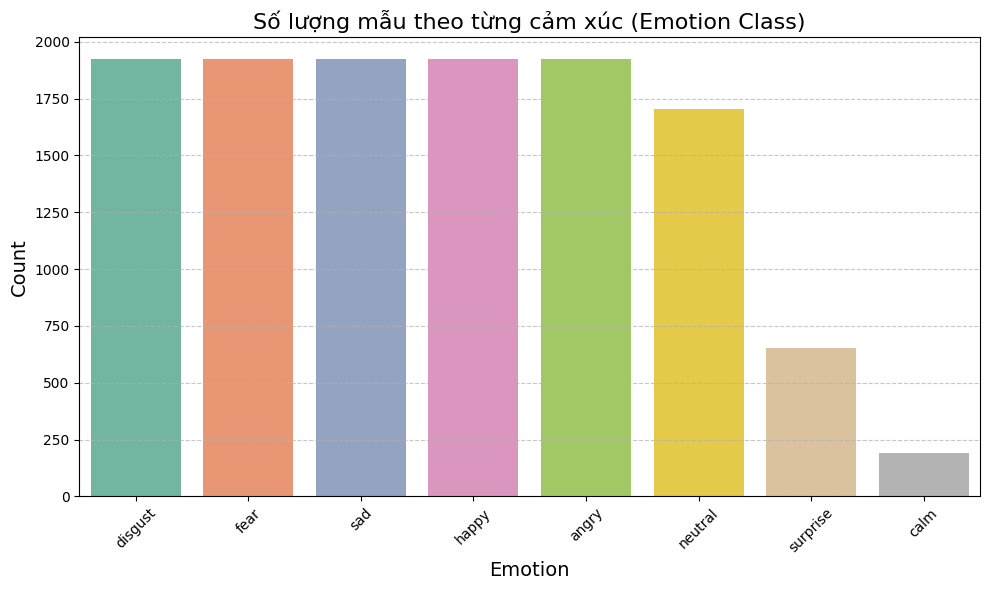

In [14]:
# Đếm số lượng mỗi class trong cột 'Emotions'
emotion_counts = data_path['Emotions'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']

# Vẽ biểu đồ cột
plt.figure(figsize=(10,6))
sns.barplot(data=emotion_counts, x='Emotion', y='Count', palette='Set2')
plt.title('Số lượng mẫu theo từng cảm xúc (Emotion Class)', fontsize=16)
plt.xlabel('Emotion', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Process


## Split train - dev - test

In [15]:
# Chia train,dev,test
# Đảm bảo phân phối cảm xúc được giữ đều (stratify)
train_df, temp_df = train_test_split( data_path,test_size=0.3, stratify=data_path['Emotions'], random_state=42)
# temp_df = test + dev = 15 + 15 % data
dev_df, test_df = train_test_split(temp_df,test_size=0.5,stratify=temp_df['Emotions'], random_state=42)


In [39]:
test_df.value_counts().sum()

1825

In [16]:
train_df['Emotions'].value_counts()

Emotions
angry       1346
sad         1346
fear        1346
disgust     1346
happy       1346
neutral     1192
surprise     456
calm         135
Name: count, dtype: int64

## Augment tập train

In [17]:
def augment_audio(path, output_dir, suffix=None):
    try:
        y, sr = librosa.load(path, sr=None)
        
        # 1. Add noise
        noise = 0.005 * np.random.randn(len(y))
        y_noise = y + noise

        # 2. Time stretch
        y_stretch = librosa.effects.time_stretch(y, rate=0.8)
        # Cắt hoặc pad để khớp độ dài
        if len(y_stretch) > len(y):
            y_stretch = y_stretch[:len(y)]
        else:
            y_stretch = np.pad(y_stretch, (0, len(y) - len(y_stretch)))

        # 3. Pitch shift
        y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=4)

        base = os.path.splitext(os.path.basename(path))[0]  # bỏ .wav
        if suffix:
            base += f"_{suffix}"

        # Lưu file
        sf.write(f"{output_dir}/{base}_noise.wav", y_noise, sr)
        sf.write(f"{output_dir}/{base}_stretch.wav", y_stretch, sr)
        sf.write(f"{output_dir}/{base}_pitch.wav", y_pitch, sr)

    except Exception as e:
        print(f"Lỗi augment file {path}: {e}")



In [18]:
# Đặt mục tiêu augment cho từng class của tập train
target_size = 1300
augmented_dir = "/kaggle/working/aug_audio_balanced"
os.makedirs(augmented_dir, exist_ok=True)


In [19]:
# Đếm số mẫu theo nhãn trong tập train
class_counts = Counter(train_df['Emotions'])

# Chỉ augment cho 3 class cần thiết
for emotion in ['neutral', 'surprise', 'calm']:
    samples = train_df[train_df['Emotions'] == emotion]['Path'].tolist()
    current = class_counts[emotion]
    needed = target_size - current
    
    print(f"Augmenting '{emotion}' — need {needed} more samples...")

    i = 0
    while needed > 0:
        path = samples[i % len(samples)]  # quay vòng qua file gốc
        augment_audio(path, augmented_dir)
        needed -= 3  # mỗi lần augment tạo 3 file
        i += 1

Augmenting 'neutral' — need 108 more samples...
Augmenting 'surprise' — need 844 more samples...
Augmenting 'calm' — need 1165 more samples...


In [20]:
# Mapping từ tên gốc sang cảm xúc
filename_to_emotion = {
    os.path.splitext(os.path.basename(row['Path']))[0]: row['Emotions']
    for _, row in train_df.iterrows()
}

def get_emotion_from_aug_name(filename):
    base = os.path.splitext(os.path.basename(filename))[0]  # 1001_DFA_ANG_XX_noise
    for suffix in ['_noise', '_pitch', '_stretch']:
        if base.endswith(suffix):
            base = base.replace(suffix, '')  # remove suffix
    return filename_to_emotion.get(base, 'unknown')


# Tạo aug_df với nhãn đúng
aug_paths = glob.glob(f"{augmented_dir}/*.wav")

aug_df = pd.DataFrame({
    'Path': aug_paths,
    'Emotions': [get_emotion_from_aug_name(p) for p in aug_paths]
})

# Gộp lại train mới
train_aug_df = pd.concat([train_df, aug_df], ignore_index=True)

In [21]:
train_aug_df['Emotions'].value_counts()

Emotions
angry       1346
sad         1346
fear        1346
disgust     1346
happy       1346
surprise    1302
neutral     1300
calm         540
Name: count, dtype: int64

In [22]:
# Xóa toàn bộ file và thư mục trong /kaggle/working
# for f in os.listdir("/kaggle/working"):
#     path = os.path.join("/kaggle/working", f)
#     if os.path.isfile(path):
#         os.remove(path)
#     else:
#         shutil.rmtree(path)


## Trích MFCC cho từng tập
- Mô hình (CNN, LSTM, MLP...) không thể xử lý trực tiếp file âm thanh (.wav).
- Chỉ nhận đầu vào là đặc trưng số học — như MFCC
- X_train, X_dev, X_test sẽ là mảng MFCC (shape: 40 × 862)

In [23]:
def extract_mfcc(file_path, n_mfcc=40, max_pad_len=862):
    try:
        audio, sr = librosa.load(file_path, sr=None)  # Giữ orginal sampling rate
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Padding or cutting
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
            
        return mfcc
    except Exception as e:
        print(f"File error {file_path}: {e}")
        return None


In [24]:
# Trích MFCC cho train_aug_df
X_train = []
y_train = []

for i, row in tqdm(train_aug_df.iterrows(), total=len(train_aug_df)):
    mfcc = extract_mfcc(row['Path'])
    if mfcc is not None:
        X_train.append(mfcc)
        y_train.append(row['Emotions'])


100%|██████████| 9872/9872 [03:25<00:00, 48.05it/s]


In [25]:
# Trích MFCC cho dev_df
X_dev = []
y_dev = []

for i, row in tqdm(dev_df.iterrows(), total=len(dev_df)):
    mfcc = extract_mfcc(row['Path'])
    if mfcc is not None:
        X_dev.append(mfcc)
        y_dev.append(row['Emotions'])

100%|██████████| 1824/1824 [00:40<00:00, 44.81it/s]


In [26]:
# Trích MFCC cho test_df
X_test = []
y_test = []

for i, row in tqdm(test_df.iterrows(), total=len(test_df)):
    mfcc = extract_mfcc(row['Path'])
    if mfcc is not None:
        X_test.append(mfcc)
        y_test.append(row['Emotions'])


100%|██████████| 1825/1825 [00:41<00:00, 44.03it/s]


In [27]:
np.save("X_train.npy", np.array(X_train))
np.save("y_train.npy", np.array(y_train))

np.save("X_dev.npy", np.array(X_dev))
np.save("y_dev.npy", np.array(y_dev))

np.save("X_test.npy", np.array(X_test))
np.save("y_test.npy", np.array(y_test))


# Encode

In [28]:
# Encode tất cả cùng 1 label encoder để đảm bảo mapping thống nhất
le = LabelEncoder()
le.fit(y_train)  # Fit trên tập train thôi

y_train_enc = le.transform(y_train)
y_dev_enc = le.transform(y_dev)
y_test_enc = le.transform(y_test)

# One-hot
y_train_ohe = to_categorical(y_train_enc)
y_dev_ohe = to_categorical(y_dev_enc)
y_test_ohe = to_categorical(y_test_enc)

# Lưu
np.save("y_train_enc.npy", y_train_enc)
np.save("y_dev_enc.npy", y_dev_enc)
np.save("y_test_enc.npy", y_test_enc)

np.save("y_train_ohe.npy", y_train_ohe)
np.save("y_dev_ohe.npy", y_dev_ohe)
np.save("y_test_ohe.npy", y_test_ohe)

# In mapping
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


2025-07-06 10:13:36.174339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751796816.482222      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751796816.569539      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Label mapping: {'angry': 0, 'calm': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}


# Model

In [29]:
# CNN + LSTM
def build_custom_model(input_shape=(40, 862, 1), num_classes=8, dropout_rate=0.3, units_lstm=128):
    
    inputs = Input(shape=input_shape)
    """
    Builds a CNN + LSTM model for speech emotion recognition using MFCC input.

    Parameters:
        input_shape (tuple): Shape of the input data (height, width, channels)
        num_classes (int): Number of emotion classes to classify

    Returns:
        model (Model): Compiled Keras model
    """

    inputs = Input(shape=input_shape)

    # CNN Block 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # CNN Block 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Reshape CNN output for LSTM input
    # From (batch_size, height, width, channels) to (batch_size, time_steps, features)
    x = Reshape((-1, x.shape[2] * x.shape[3]))(x)


    # LSTM Layer
    x = LSTM(128, return_sequences=False)(x)
    x = Dropout(0.3)(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs, outputs)
    return model


In [30]:
#Train model with augmented data

# Load
X_train = np.load("/kaggle/working/X_train.npy")[..., np.newaxis]
X_val   = np.load("/kaggle/working/X_dev.npy")[..., np.newaxis]
X_test  = np.load("/kaggle/working/X_test.npy")[..., np.newaxis]

y_train = np.load("/kaggle/working/y_train_ohe.npy")
y_val   = np.load("/kaggle/working/y_dev_ohe.npy")
y_test  = np.load("/kaggle/working/y_test_ohe.npy")

model = build_custom_model()
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-5,verbose=1)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stop,reduce_lr],
    verbose=1
)

# Đánh giá trên tập test
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test accuracy: {test_acc:.4f}")

2025-07-06 10:14:06.355211: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 720s 2s/step - accuracy: 0.2813 - loss: 1.8524 - val_accuracy: 0.3695 - val_loss: 1.6095 - learning_rate: 0.0010
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - accuracy: 0.4266 - loss: 1.5069 - val_accuracy: 0.4304 - val_loss: 1.4500 - learning_rate: 0.0010
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.4843 - loss: 1.3629 - val_accuracy: 0.4375 - val_loss: 1.4152 - learning_rate: 0.0010
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 716s 2s/step - accuracy: 0.5108 - loss: 1.2669 - val_accuracy: 0.4232 - val_loss: 1.4603 - learning_rate: 0.0010
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 735s 2s/step - accuracy: 0.5528 - loss: 1.1721 - val_accuracy: 0.4688 - val_loss: 1.3528 - learning_rate: 0.0010
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.5680 - loss: 1.1255 - val_accuracy: 0.4605 - val_loss: 1.3523 - learning_rate: 0.0010
Epoch 7/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.5932 - loss: 1.

# Evaluate Model

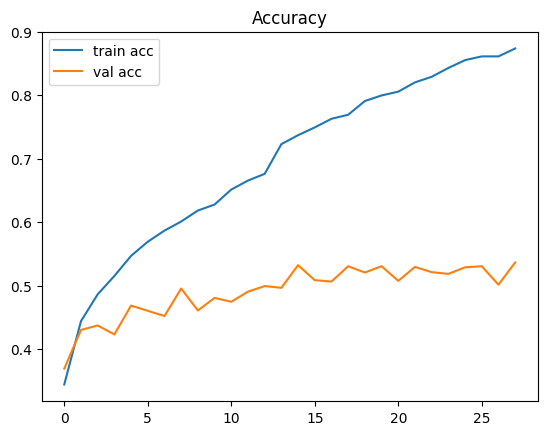

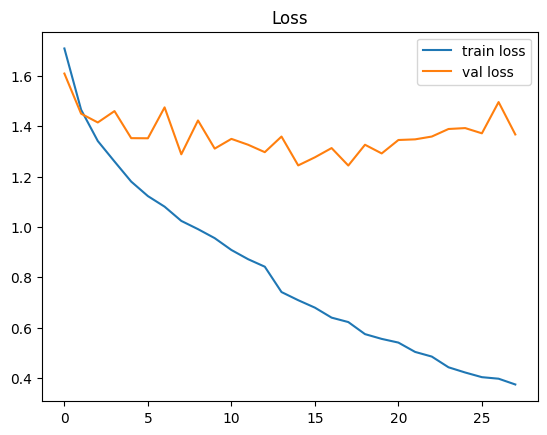

In [31]:
# Vẽ đồ thị accuracy giữa train - val
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Train vs Validation Accuracy on augmented-data-model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 374ms/step


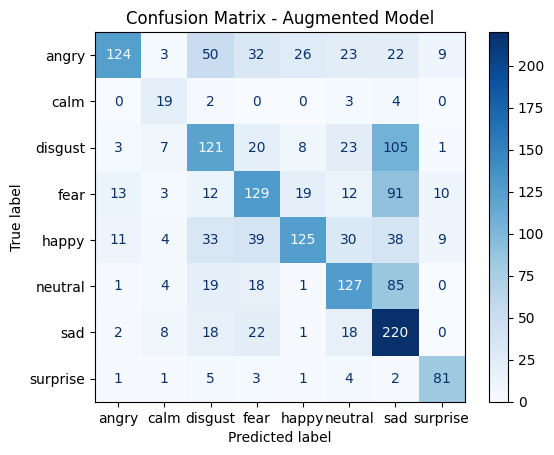

In [35]:
# Confusion matrix

# Dự đoán nhãn trên tập test
y_pred_aug = np.argmax(model.predict(X_test), axis=1)
y_true_aug = np.argmax(y_test, axis=1)

# Tạo confusion matrix
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

# Hiển thị confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Augmented Model")
plt.show()


In [41]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Giả sử bạn đã có:
# y_true: ground truth (label thật)
# y_pred: dự đoán (dạng số nguyên, sau argmax nếu dùng softmax)

# Ví dụ: nếu dùng one-hot thì phải argmax:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("✅ Accuracy:", acc)

# F1, Precision, Recall
print("🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))


58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 363ms/step
✅ Accuracy: 0.5183561643835617
🔍 Classification Report:
              precision    recall  f1-score   support

       angry       0.80      0.43      0.56       289
        calm       0.39      0.68      0.49        28
     disgust       0.47      0.42      0.44       288
        fear       0.49      0.45      0.47       289
       happy       0.69      0.43      0.53       289
     neutral       0.53      0.50      0.51       255
         sad       0.39      0.76      0.51       289
    surprise       0.74      0.83      0.78        98

    accuracy                           0.52      1825
   macro avg       0.56      0.56      0.54      1825
weighted avg       0.57      0.52      0.52      1825

